# WTI Crude Oil Price Forecasting — Introducing the Agentic Predictor (Notebook 2)

This notebook introduces the **progressive capability staircase** for agentic
forecasting by studying a single, high-stakes prediction origin:
**March 2, 2026** — the day news of Persian Gulf shipping-lane disruptions
began reaching energy markets.

> **Prerequisite:** Run [`01_wti_case_study.ipynb`](01_wti_case_study.ipynb) first — it establishes why a price-only baseline fails during regime breaks.

We build four predictors of increasing sophistication, each implementing
the standard `Predictor` interface so that the outputs are directly
comparable and can slot into the systematic backtest in Notebook 4.

| Step | Predictor | Capability |
|------|-----------|------------|
| 1 | `ProphetPredictor` | Statistical baseline — extrapolates trend and seasonality |
| 2 | `ContinuousLLMPredictor` | Direct-prompting LLMP — no tools, reasons from history text |
| 3 | `AgentPredictor` (news) | News-grounded agent — bounded Google Search, strict temporal cutoff |
| 4 | `AgentPredictor` (code+news) | Code-executing agent — Gemini native code execution + 2 forecasting skills |

---
## 1. Setup & Data Registration

In [1]:
import warnings


warnings.filterwarnings("ignore")

import pandas as pd
from energy_oil_forecasting.data import WTI_SERIES_ID, build_wti_service


# ── Data service ──────────────────────────────────────────────────────────
data_service = build_wti_service()

# ── Single forecast origin for this notebook ──────────────────────────────
AS_OF = pd.Timestamp("2026-03-01")  # context available the day before origin
ORIGIN = pd.Timestamp("2026-03-02")  # the day we are predicting *from*

ctx = data_service.context(as_of=AS_OF)
full_df = ctx.get_series(WTI_SERIES_ID)

print(f"Trading days in cache up to {AS_OF.date()}: {len(full_df)}")
print(f"Last WTI close: ${full_df['value'].iloc[-1]:.2f}/bbl on {str(full_df['timestamp'].iloc[-1])[:10]}")

Trading days in cache up to 2026-03-01: 5569
Last WTI close: $65.21/bbl on 2026-02-26


In [2]:
from aieng.forecasting.evaluation.task import ForecastingTask


# The forecasting task mirrors the spec in specs/energy_oil_backtest.yaml
task = ForecastingTask(
    task_id="wti_oil_price_forecast",
    target_series_id=WTI_SERIES_ID,
    horizons=[5, 10, 21],
    frequency="B",
    description="WTI Crude Oil front-month futures — 5, 10, 21 business days ahead.",
)

print("Task:", task.task_id)
print("Horizons:", task.horizons)
print("Origin context as_of:", ctx.as_of)

Task: wti_oil_price_forecast
Horizons: [5, 10, 21]
Origin context as_of: 2026-03-01 00:00:00


---
## 2. Step 1 — Prophet Baseline

Prophet fits a decomposable time-series model (trend + seasonality) on the
daily close history. It is deliberately blind to geopolitics — whatever
is happening in the Persian Gulf, Prophet does not know.

We wrap Prophet in a `Predictor` subclass so it produces standard
`Prediction` objects with the full 11-quantile grid.
The same wrapper will be used in Notebook 4's backtest loop.

In [3]:
from energy_oil_forecasting.prophet_baseline import ProphetPredictor


prophet = ProphetPredictor()

In [4]:
prophet_preds = prophet.predict(task, ctx)

print(f"Prophet forecast from {AS_OF.date()} (as_of) → {ORIGIN.date()} (origin):\n")
for p in prophet_preds:
    fc = p.payload
    print(
        f"  h={task.horizons[prophet_preds.index(p)]:>2}d  "
        f"point=${fc.point_forecast:.2f}  "
        f"80%CI=[${fc.quantiles[0.10]:.2f}, ${fc.quantiles[0.90]:.2f}]"
    )

06:53:16 - cmdstanpy - INFO - Chain [1] start processing
06:53:17 - cmdstanpy - INFO - Chain [1] done processing


Prophet forecast from 2026-03-01 (as_of) → 2026-03-02 (origin):

  h= 5d  point=$64.67  80%CI=[$57.34, $72.00]
  h=10d  point=$64.59  80%CI=[$56.96, $72.22]
  h=21d  point=$64.27  80%CI=[$57.07, $71.48]


---
## 3. Step 2 — Direct-Prompting LLM Process (LLMP)

`ContinuousLLMPredictor` sends the price history as a structured JSON payload
directly to Gemini and asks it to return a calibrated probabilistic forecast.
There is no search tool and no code execution — the model must reason entirely
from numerical history.

**Data leakage caveat:** Gemini was trained on data that includes WTI prices
through at least late 2024. For origins in 2026, the model may have implicit
knowledge of historical events — this is a known limitation of LLMPs that we
cannot fully control. The LLMP is included as a calibration reference, not as
a clean counterfactual.

In [5]:
from aieng.forecasting.methods import ContinuousLLMPredictor, ContinuousLLMPredictorConfig


llmp_config = ContinuousLLMPredictorConfig(
    model="gemini/gemini-3.5-flash",
    n_samples=3,
)

print("ContinuousLLMPredictorConfig:")
print(f"  model:    {llmp_config.model}")
print(f"  n_samples: {llmp_config.n_samples}")

ContinuousLLMPredictorConfig:
  model:    gemini/gemini-3.5-flash
  n_samples: 3


In [6]:
llmp = ContinuousLLMPredictor(llmp_config)
llmp_preds = llmp.predict(task, ctx)

print("LLMP forecast (no tools):\n")
for p in llmp_preds:
    fc = p.payload
    print(
        f"  h={task.horizons[llmp_preds.index(p)]:>2}d  "
        f"point=${fc.point_forecast:.2f}  "
        f"80%CI=[${fc.quantiles[0.10]:.2f}, ${fc.quantiles[0.90]:.2f}]"
    )

06:53:18 - LiteLLM:WARNING: common_utils.py:979 - litellm: could not pre-load bedrock-runtime response stream shape — Bedrock event-stream decoding will be unavailable. Error: No module named 'botocore'
06:53:18 - LiteLLM:WARNING: common_utils.py:24 - litellm: could not pre-load sagemaker-runtime response stream shape — SageMaker event-stream decoding will be unavailable. Error: No module named 'botocore'
06:53:18 - LiteLLM:WARNING: opentelemetry.py:230 - Proxy Server is not installed. Skipping OpenTelemetry initialization.


LLMP forecast (no tools):

  h= 5d  point=$64.71  80%CI=[$63.50, $64.95]
  h=10d  point=$65.78  80%CI=[$64.45, $66.72]
  h=21d  point=$67.68  80%CI=[$66.22, $69.17]


---
## 4. Step 3 — News-Grounded Agent

We import `build_wti_news_config` from the `analyst_agent` module and wrap it
in an `AgentPredictor`. The config wires a `ContextRetrievalConfig` sub-agent
that uses Google Search with a strict `cutoff_date` enforcement.

The key design constraints — visible in the config below — are:
- The root agent's instruction contains three sections: `## Role`,
  `## Forecasting contract`, and `## Analysis discipline`.
- The context sub-agent's instruction reads `cutoff_date` and `query` from
  the incoming JSON payload (produced by `ContextRetrievalRequest`).
- The prompt builder sends a structured JSON payload, not a free-form string,
  including `standard_quantiles` explicitly.

In [7]:
from energy_oil_forecasting.analyst_agent import (
    WtiPriceForecastPromptBuilder,
    build_wti_agent_predictor,
    build_wti_news_config,
)


news_config = build_wti_news_config()

print("=== Root agent instruction (first 1000 chars) ===")
print(news_config.instruction[:1000])
print("\n=== Context retrieval instruction (first 500 chars) ===")
print(news_config.context_retrieval.instruction[:500])
print("\nContext retrieval enabled:", news_config.context_retrieval.enabled)
print("Context retrieval model:", news_config.context_retrieval.model)

=== Root agent instruction (first 1000 chars) ===
## Role

You are an expert WTI crude oil market analyst. You produce calibrated probabilistic price forecasts for WTI crude oil futures, grounded in supply/demand fundamentals, geopolitical risk, and historical price dynamics.

## Forecasting contract

You will receive a JSON payload containing:
- `task`: the task identifier
- `as_of`: the forecast origin date in YYYY-MM-DD format
- `horizons`: a list of integer horizon steps (business days ahead)
- `standard_quantiles`: the exact quantile levels you must produce
- `target_summary`: last close price, 52-week range, and observation count
- `target_history_csv`: WTI daily close history (recent 6 months daily, older history as weekly averages)

Rules:
1. Produce one forecast for each horizon listed in `horizons`.
2. Use exactly the quantile levels from `standard_quantiles` — no additions, no omissions.
3. `point_forecast` must exactly equal the 0.50 quantile value.
4. Quantile values must 

In [8]:
# Inspect the prompt payload that will be sent to the agent
prompt_builder = WtiPriceForecastPromptBuilder()
sample_prompt = prompt_builder(task=task, context=ctx)

print("=== Prompt payload sent to agent (first 800 chars) ===")
print(sample_prompt[:800])
print("\n...[history_csv truncated]...")

=== Prompt payload sent to agent (first 800 chars) ===
{
  "task": "wti_oil_price_forecast",
  "as_of": "2026-03-01",
  "horizons": [
    5,
    10,
    21
  ],
  "standard_quantiles": [
    0.05,
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9,
    0.95
  ],
  "target_summary": {
    "last_close_usd_bbl": 65.20999908447266,
    "last_date": "2026-02-26",
    "n_trading_days": 5569,
    "52w_high": 75.13999938964844,
    "52w_low": 55.27000045776367
  },
  "target_history_csv": "date,close\n2004-01-11,33.88\n2004-01-18,34.43\n2004-01-25,35.16\n2004-02-01,33.61\n2004-02-08,33.55\n2004-02-15,33.85\n2004-02-22,35.55\n2004-02-29,35.26\n2004-03-07,36.64\n2004-03-14,36.38\n2004-03-21,37.82\n2004-03-28,36.56\n2004-04-04,35.22\n2004-04-11,35.66\n2004-04-18,37.42\n2004-04-25,36.78\n2004-05-02,37.33\n2004-05-09,39.21\n200

...[history_csv truncated]...


In [13]:
news_predictor = build_wti_agent_predictor(news_config)

print(f"Predictor ID: {news_predictor.predictor_id}")
print("Running news-grounded agent... (this calls Google Search)")

news_preds = news_predictor.predict(task, ctx)

print("\nNews-grounded agent forecast:\n")
for p in news_preds:
    fc = p.payload
    print(
        f"  h={task.horizons[news_preds.index(p)]:>2}d  "
        f"point=${fc.point_forecast:.2f}  "
        f"80%CI=[${fc.quantiles[0.10]:.2f}, ${fc.quantiles[0.90]:.2f}]"
    )
if news_preds and news_preds[0].metadata.get("agent_rationale"):
    print("\nAgent rationale:", news_preds[0].metadata["agent_rationale"][:400])

Predictor ID: agent_predictor_wti_analyst_news_gemini-3.5-flash_continuous
Running news-grounded agent... (this calls Google Search)


Task was destroyed but it is pending!
task: <Task pending name='Task-273' coro=<<async_generator_athrow without __name__>()>>
Failed to detach context
Traceback (most recent call last):
  File "/Users/ethanjackson/agentic-forecasting/.venv/lib/python3.12/site-packages/opentelemetry/trace/__init__.py", line 589, in use_span
    yield span
  File "/Users/ethanjackson/agentic-forecasting/.venv/lib/python3.12/site-packages/openinference/instrumentation/_tracers.py", line 141, in start_as_current_span
    yield cast(OpenInferenceSpan, current_span)
GeneratorExit

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/ethanjackson/agentic-forecasting/.venv/lib/python3.12/site-packages/opentelemetry/context/__init__.py", line 155, in detach
    _RUNTIME_CONTEXT.detach(token)
  File "/Users/ethanjackson/agentic-forecasting/.venv/lib/python3.12/site-packages/opentelemetry/context/contextvars_context.py", line 53, in detach
    self


News-grounded agent forecast:

  h= 5d  point=$75.00  80%CI=[$69.00, $90.00]
  h=10d  point=$76.00  80%CI=[$68.00, $95.00]
  h=21d  point=$74.00  80%CI=[$64.00, $100.00]

Agent rationale: On February 28, 2026, the US and Israel launched coordinated military strikes against Iran (Operation Epic Fury), drastically elevating geopolitical risk. With WTI closing at $67.02/bbl on Friday, Feb 27, before the strikes, we project a massive price shock when markets reopen. 

Key Assumptions:
1. Geopolitical Risk & Shipping Chokepoints: The immediate fear premium is estimated at $5 to $10/bbl.


---
## 5. Step 4 — Code-Executing Agent (Gemini Native)

`build_wti_code_exec_config()` adds two capabilities on top of the news config:

1. **Gemini native code execution** (`provider='gemini_native'`) — the agent
   can write and run Python (pandas, numpy, scikit-learn, matplotlib) inside
   Gemini's sandboxed environment, see the output, and iterate before producing
   its final structured forecast.

2. **Two forecasting skills** — ADK `SkillToolset` provides reference data
   and code patterns on demand:
   - `statistical-analysis` — diagnostic patterns for the payload data (vol
     regime, anomaly detection, adaptive trend-window selection)
   - `trend-projection` — linear trend fit, CI calibration, and plausibility
     guard using the window determined by statistical-analysis

The skills follow the design rule from `docs/adk-skills-guide.md`: each
skill directory contains at least one real file in `references/` and the
instruction explicitly tells the agent **not** to call `run_skill_script`.

### Design constraints and skill philosophy

**Context is your data store.** In this Gemini code-exec design, all data
the agent can use in code must arrive via the JSON payload in the user
message. The payload fields are:

| Field | Contents |
|---|---|
| `target_history_csv` | Mixed-frequency CSV string — recent 6 months daily, older history as weekly averages |
| `target_summary` | `last_close_usd_bbl`, `last_date`, `52w_high`, `52w_low`, `n_trading_days` |
| `as_of` | Forecast origin date |
| `horizons` | Integer list of horizon steps (business days) |
| `standard_quantiles` | Exact quantile grid the agent must produce |

There are no disk files, no database connections. The agent parses
`target_history_csv` using `io.StringIO` (not a file path), emits
intermediate results via `print()` so they appear in the conversation, and
can reference a parsed DataFrame across multiple code blocks because Gemini's
execution session is stateful within a single turn.

**Skill philosophy.** The skills don't teach the agent how to use sklearn —
it already knows that. They signal *which analyses are worth running given the
payload you have*, and show the best way to get data in and structured results
out of the code execution environment. The patterns are illustrated with WTI
but the approach transfers: classify your vol regime, detect anomalies, adapt
your trend window accordingly.

**Natural ceiling.** Injecting data via context tokens is the right tradeoff
for a few hundred rows of compressed price history. If you wanted to bootstrap
the agent with megabytes of tick data, correlated series, or frequently-updated
data files, you would need an E2B-equipped agent where the Docker container is
pre-loaded with files before the turn starts. That is a different architecture
tier and not a near-term extension of this reference.

**TODO (futures curve).** The natural next payload extension for WTI is a
futures curve snapshot — spot vs M1, M3, M6 spread (a few numbers, low token
cost) — which would unlock contango/backwardation regime detection in code.
See `WtiPriceForecastPromptBuilder` in `analyst_agent/agent.py` for where this
field would be added, and `statistical-analysis/references/analysis-patterns.md`
for where the corresponding pattern would live.

In [10]:
from energy_oil_forecasting.analyst_agent import build_wti_code_exec_config


code_config = build_wti_code_exec_config()

print("=== Code-exec agent config summary ===")
print(f"Code execution provider: {code_config.code_execution.provider}")
print(f"Code execution enabled:  {code_config.code_execution.enabled}")
print(f"Include server-side tool invocations: {code_config.code_execution.include_server_side_tool_invocations}")
print(f"Skills directories ({len(code_config.skills_dirs)}):")
for sd in code_config.skills_dirs:
    print(f"  {sd.name}")
print("\n=== Skills supplement in instruction (last 600 chars of instruction) ===")
print(code_config.instruction[-600:])

=== Code-exec agent config summary ===
Code execution provider: gemini_native
Code execution enabled:  True
Include server-side tool invocations: True
Skills directories (3):
  rolling-statistics
  trend-projection
  forecast-visualization

=== Skills supplement in instruction (last 600 chars of instruction) ===
ment your key assumptions (OPEC+ policy, shipping lane risk, inventory levels, macro demand) in the `rationale` fields of your forecast output.

## Skills

You have access to forecasting skills via the SkillToolset.

Before using any skill:
1. Call `list_skills` to see the available skill names and descriptions.
2. Call `load_skill(<name>)` to read the skill's full instructions.
3. Call `load_skill_resource(<skill_name>, <file_path>)` to load reference data (e.g. `references/wti_benchmarks.json`).

These skills provide reference data only — they have NO scripts. Do not call `run_skill_script`.


In [11]:
code_predictor = build_wti_agent_predictor(code_config)

print(f"Predictor ID: {code_predictor.predictor_id}")
print("Running code-executing agent... (calls Google Search + executes Python code)")

code_preds = code_predictor.predict(task, ctx)

print("\nCode-executing agent forecast:\n")
for p in code_preds:
    fc = p.payload
    print(
        f"  h={task.horizons[code_preds.index(p)]:>2}d  "
        f"point=${fc.point_forecast:.2f}  "
        f"80%CI=[${fc.quantiles[0.10]:.2f}, ${fc.quantiles[0.90]:.2f}]"
    )
if code_preds and code_preds[0].metadata.get("agent_rationale"):
    print("\nAgent rationale:", code_preds[0].metadata["agent_rationale"][:400])

Predictor ID: agent_predictor_wti_analyst_code_gemini-3.5-flash_continuous
Running code-executing agent... (calls Google Search + executes Python code)


Task was destroyed but it is pending!
task: <Task pending name='Task-226' coro=<<async_generator_athrow without __name__>()>>
Failed to detach context
Traceback (most recent call last):
  File "/Users/ethanjackson/agentic-forecasting/.venv/lib/python3.12/site-packages/opentelemetry/trace/__init__.py", line 589, in use_span
    yield span
  File "/Users/ethanjackson/agentic-forecasting/.venv/lib/python3.12/site-packages/openinference/instrumentation/_tracers.py", line 141, in start_as_current_span
    yield cast(OpenInferenceSpan, current_span)
GeneratorExit

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/ethanjackson/agentic-forecasting/.venv/lib/python3.12/site-packages/opentelemetry/context/__init__.py", line 155, in detach
    _RUNTIME_CONTEXT.detach(token)
  File "/Users/ethanjackson/agentic-forecasting/.venv/lib/python3.12/site-packages/opentelemetry/context/contextvars_context.py", line 53, in detach
    self


Code-executing agent forecast:

  h= 5d  point=$86.33  80%CI=[$71.22, $102.44]
  h=10d  point=$89.71  80%CI=[$68.80, $112.43]
  h=21d  point=$91.56  80%CI=[$65.22, $125.65]

Agent rationale: As of the March 1, 2026 forecast origin, WTI crude oil is undergoing a massive structural shift due to a major geopolitical shock: the joint US-Israeli military campaign (Operation Epic Fury) launched on February 28, which resulted in the death of Iran's Supreme Leader and Iran's immediate retaliatory blockade of the Strait of Hormuz. While baseline pre-conflict forecasts for 2026 WTI were structu


---
## 6. Side-by-Side Comparison

All four predictors return standard `Prediction` objects, so we can
compare them in a uniform table. We also show the actual WTI prices
at each horizon to contextualise the forecasts.

In [14]:
import matplotlib.pyplot as plt
import numpy as np


# Collect actual prices for horizon dates
future_ctx = data_service.context(as_of=ORIGIN + pd.offsets.BDay(25))
future_df = future_ctx.get_series(WTI_SERIES_ID)


def get_actual(h: int) -> float | None:
    target = ORIGIN + pd.offsets.BDay(h)
    future_df["ts"] = pd.to_datetime(future_df["timestamp"])
    row = future_df[future_df["ts"] >= target]
    if row.empty:
        return None
    return float(row.iloc[0]["value"])


# Build comparison table
rows = []
predictor_sets = [
    ("Prophet", prophet_preds),
    ("LLMP", llmp_preds),
    ("Agent (News)", news_preds),
    ("Agent (Code+News)", code_preds),
]

for h_idx, h in enumerate(task.horizons):
    actual = get_actual(h)
    for name, preds in predictor_sets:
        if preds and h_idx < len(preds):
            fc = preds[h_idx].payload
            rows.append(
                {
                    "Horizon": f"h={h}d",
                    "Predictor": name,
                    "Point ($)": f"{fc.point_forecast:.2f}",
                    "p10 ($)": f"{fc.quantiles[0.10]:.2f}",
                    "p90 ($)": f"{fc.quantiles[0.90]:.2f}",
                    "Actual ($)": f"{actual:.2f}" if actual else "N/A",
                }
            )

import pandas as pd


comparison = pd.DataFrame(rows).set_index(["Horizon", "Predictor"])
print(comparison.to_string())

                          Point ($) p10 ($) p90 ($) Actual ($)
Horizon Predictor                                             
h=5d    Prophet               64.67   57.34   72.00      94.77
        LLMP                  64.71   63.50   64.95      94.77
        Agent (News)          75.00   69.00   90.00      94.77
        Agent (Code+News)     86.33   71.22  102.44      94.77
h=10d   Prophet               64.59   56.96   72.22      93.50
        LLMP                  65.78   64.45   66.72      93.50
        Agent (News)          76.00   68.00   95.00      93.50
        Agent (Code+News)     89.71   68.80  112.43      93.50
h=21d   Prophet               64.27   57.07   71.48     101.38
        LLMP                  67.68   66.22   69.17     101.38
        Agent (News)          74.00   64.00  100.00     101.38
        Agent (Code+News)     91.56   65.22  125.65     101.38


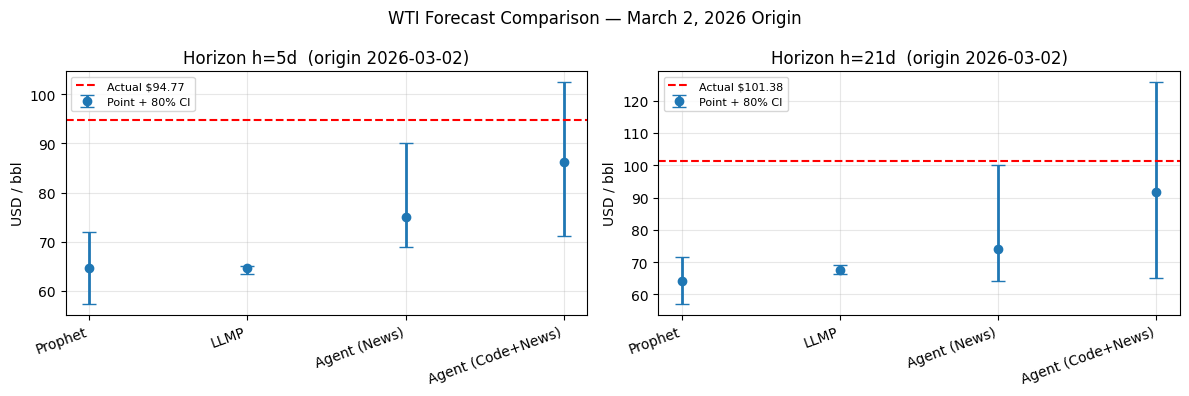

In [15]:
# Point forecast comparison chart (h=5 and h=21)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, h_idx, h in [(axes[0], 0, 5), (axes[1], 2, 21)]:
    names, points, lo, hi, actuals = [], [], [], [], []
    actual_val = get_actual(h)

    for name, preds in predictor_sets:
        if preds and h_idx < len(preds):
            fc = preds[h_idx].payload
            names.append(name)
            points.append(fc.point_forecast)
            lo.append(fc.quantiles[0.10])
            hi.append(fc.quantiles[0.90])

    x = range(len(names))
    ax.errorbar(
        x,
        points,
        yerr=[np.array(points) - np.array(lo), np.array(hi) - np.array(points)],
        fmt="o",
        capsize=5,
        linewidth=2,
        label="Point + 80% CI",
    )
    if actual_val:
        ax.axhline(actual_val, color="red", linestyle="--", label=f"Actual ${actual_val:.2f}")
    ax.set_xticks(list(x))
    ax.set_xticklabels(names, rotation=20, ha="right")
    ax.set_title(f"Horizon h={h}d  (origin {ORIGIN.date()})")
    ax.set_ylabel("USD / bbl")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("WTI Forecast Comparison — March 2, 2026 Origin", fontsize=12)
plt.tight_layout()
plt.show()

---
## Key Takeaways

1. **All four predictors share the same `Predictor` interface.** The same
   `predict(task, context)` call works whether the model is a statistical
   trend-fitter or a tool-using agent. This is what makes systematic
   backtesting in Notebook 4 possible.

2. **`AgentConfig` factories encapsulate capability.** By importing
   `build_wti_news_config()` and `build_wti_code_exec_config()` from
   `analyst_agent/`, the notebook stays clean — configs are reproducible and
   importable from any script or notebook.

3. **Skills guide code execution, not sklearn usage.** The two ADK skills
   (`statistical-analysis`, `trend-projection`) provide payload-aware code
   patterns and reference benchmarks the agent loads on demand. They teach
   effective use of code exec within the Gemini context-as-data-store
   constraints — not Python basics. Following the design rule in
   `docs/adk-skills-guide.md`, no scripts are present and the instruction
   explicitly forbids `run_skill_script`.

4. **Temporal cutoffs prevent data leakage.** The `ContextRetrievalConfig`
   sub-agent enforces a `cutoff_date` on every search call, allowing the same
   agent to be used safely in historical backtests.

→ **Notebook 4** runs a full 2025 backtest across all predictors, selects
the top contenders, and evaluates them on the protected 2026 eval period.